In [6]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

def plot_training_results(csv_path):
    sns.set_theme(style="whitegrid")
    
    # 1. Load the data from CSV
    try:
        df = pd.read_csv(csv_path)
    except FileNotFoundError:
        print(f"Error: File {csv_path} not found.")
        return

    # Check if required columns exist
    required_cols = ['epoch', 'train_loss', 'eval_loss', 'eval_top1', 'eval_top5']
    if not all(col in df.columns for col in required_cols):
        print(f"Error: CSV must contain {required_cols}")
        return

    # 2. Create the figure and subplots
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))
    fig.suptitle('Model Training Metrics', fontsize=16, fontweight='bold')

    # --- Subplot 1: Loss Curves ---
    # 绘制训练损失和验证损失曲线
    ax1.plot(df['epoch'], df['train_loss'], label='Train Loss', color='#1f77b4', linewidth=2, marker='o', markersize=4)
    ax1.plot(df['epoch'], df['eval_loss'], label='Eval Loss', color='#ff7f0e', linewidth=2, linestyle='--', marker='s', markersize=4)
    
    ax1.set_title('Training and Evaluation Loss', fontsize=14)
    ax1.set_xlabel('Epoch', fontsize=12)
    ax1.set_ylabel('Loss', fontsize=12)
    ax1.legend(frameon=True)
    ax1.grid(True, linestyle=':', alpha=0.6)

    # --- Subplot 2: Accuracy Curves ---
    # 绘制 Top-1 和 Top-5 精度曲线
    ax2.plot(df['epoch'], df['eval_top1'], label='Top-1 Accuracy', color='#2ca02c', linewidth=2, marker='^', markersize=5)
    ax2.plot(df['epoch'], df['eval_top5'], label='Top-5 Accuracy', color='#d62728', linewidth=2, marker='v', markersize=5)
    
    ax2.set_title('Evaluation Accuracy', fontsize=14)
    ax2.set_xlabel('Epoch', fontsize=12)
    ax2.set_ylabel('Accuracy (%)', fontsize=12)
    ax2.legend(loc='lower right', frameon=True)
    ax2.grid(True, linestyle=':', alpha=0.6)

    # 3. Optional: Add Learning Rate on a twin axis in Subplot 1
    # 可选：在 Loss 图中添加学习率曲线（使用右侧 Y 轴）
    if 'lr' in df.columns:
        ax1_lr = ax1.twinx()
        ax1_lr.plot(df['epoch'], df['lr'], color='gray', alpha=0.3, label='LR')
        ax1_lr.set_ylabel('Learning Rate', color='gray', fontsize=10)
        ax1_lr.tick_params(axis='y', labelcolor='gray')

    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    
    plt.savefig('training_curves.png', dpi=300)
    print("Plot saved as 'training_curves.png'")
    plt.show()

Plot saved as 'training_curves.png'


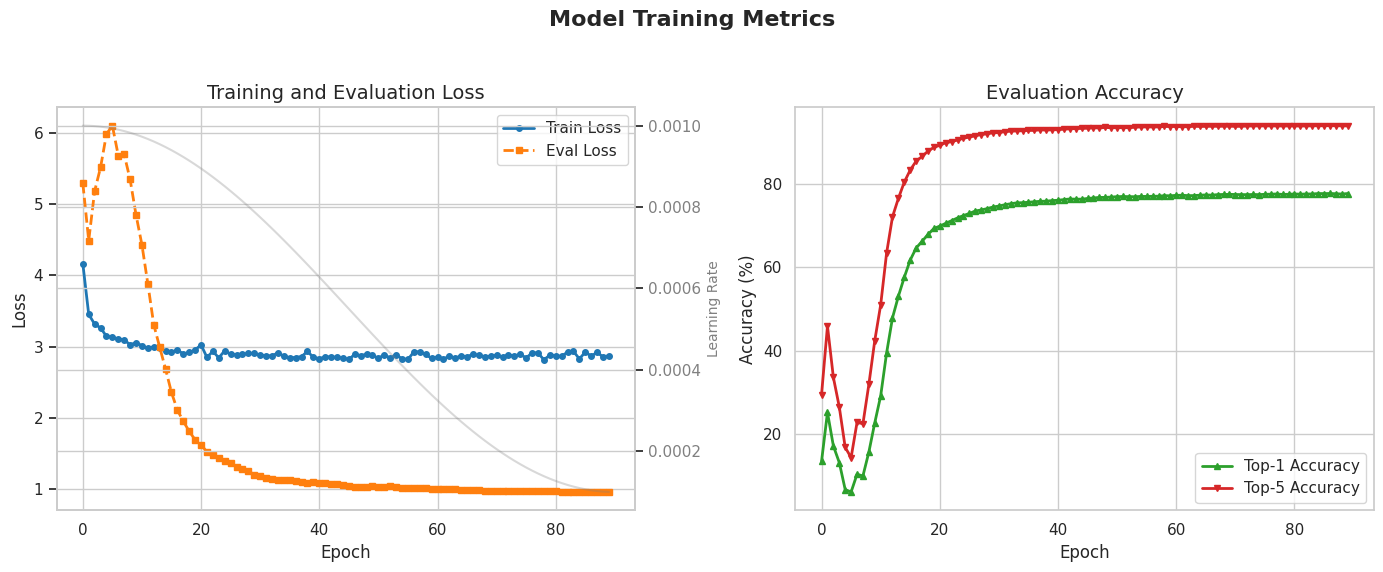

In [7]:
plot_training_results('/home/chenzhiqiang/MaskLLM-4V/output/sparse_deit_small_patch16_224_90_epochs_lr1e-3_.augreg_in1k.hybird/HybirdSparse/summary.csv')

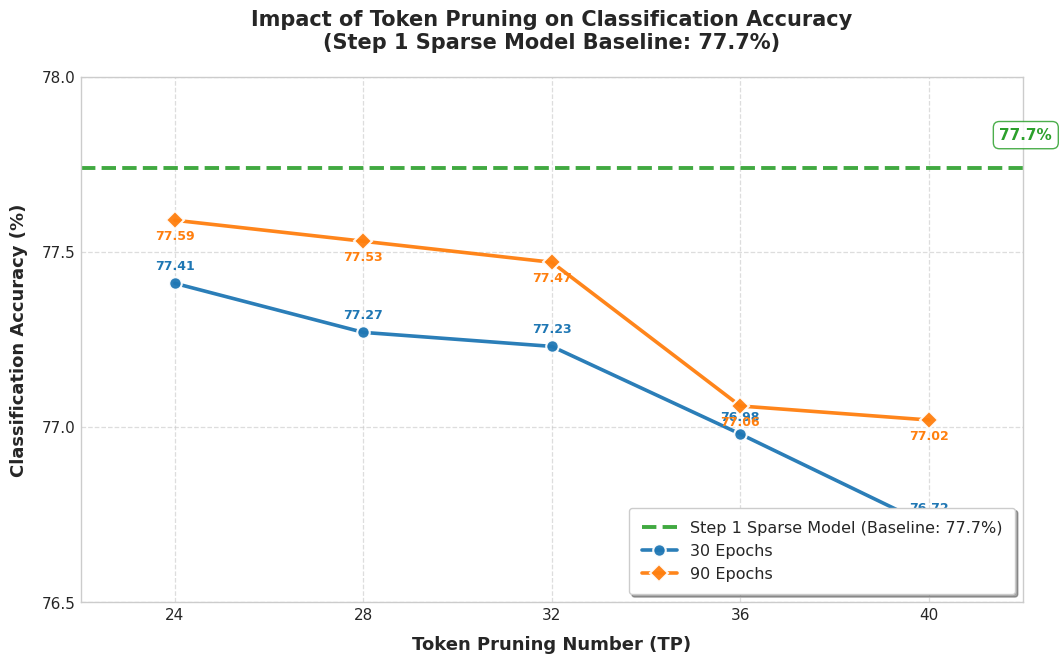

In [6]:
import matplotlib.pyplot as plt
import numpy as np

# 数据准备
tp_values = [24, 28, 32, 36, 40]
acc_30epochs = [77.41, 77.27, 77.23, 76.98, 76.72]
acc_90epochs = [77.59, 77.53, 77.47, 77.06, 77.02]
baseline_acc = 77.74  # Dense 模型精度基线

# 创建图形（使用更现代的样式）
plt.figure(figsize=(11, 7))
plt.style.use('seaborn-v0_8-whitegrid')  # 清爽背景 + 网格

# 绘制 Dense 模型基线（突出显示）
plt.axhline(y=baseline_acc, color='#2ca02c', linestyle='--', linewidth=2.8,
            label=f'Step 1 Sparse Model (Baseline: {baseline_acc:.1f}%)', alpha=0.9)
# 基线右侧标注（带背景框）
plt.text(tp_values[-1] + 1.5, baseline_acc + 0.08, f'{baseline_acc:.1f}%',
         fontsize=11, fontweight='bold', color='#2ca02c',
         bbox=dict(facecolor='white', edgecolor='#2ca02c', alpha=0.85, boxstyle='round,pad=0.4'))

# 绘制训练曲线（优化颜色与标记）
plt.plot(tp_values, acc_30epochs,
         marker='o', linewidth=2.6, markersize=9, markeredgewidth=1.5,
         label='30 Epochs', color='#1f77b4', markeredgecolor='white', alpha=0.95)
plt.plot(tp_values, acc_90epochs,
         marker='D', linewidth=2.6, markersize=9, markeredgewidth=1.5,
         label='90 Epochs', color='#ff7f0e', markeredgecolor='white', alpha=0.95)

# 坐标轴与标题（增强专业感）
plt.xlabel('Token Pruning Number (TP)', fontsize=13, fontweight='bold', labelpad=10)
plt.ylabel('Classification Accuracy (%)', fontsize=13, fontweight='bold', labelpad=10)
plt.title('Impact of Token Pruning on Classification Accuracy\n'
          f'(Step 1 Sparse Model Baseline: {baseline_acc:.1f}%)',
          fontsize=15, fontweight='bold', pad=20, loc='center')

# 图例（右下角，避免遮挡曲线与基线）
plt.legend(loc='lower right', fontsize=11.5, frameon=True, shadow=True,
           fancybox=True, borderpad=0.8, handlelength=2.2)

# 网格与坐标轴优化
plt.grid(True, linestyle='--', alpha=0.65, linewidth=0.9, which='both')
plt.xticks(tp_values, fontsize=11)
plt.yticks(np.arange(76.0, 80.1, 0.5), fontsize=11)
plt.ylim(76.5, 78.0)  # 留出基线上方空间
plt.xlim(22, 42)      # 横轴微扩，避免点贴边

# 数据标签（智能偏移，避免重叠）
for i, (x, y) in enumerate(zip(tp_values, acc_30epochs)):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, 10),
                 ha='center', fontsize=9, color='#1f77b4', fontweight='bold')
for i, (x, y) in enumerate(zip(tp_values, acc_90epochs)):
    plt.annotate(f'{y:.2f}', (x, y), textcoords="offset points", xytext=(0, -14),
                 ha='center', fontsize=9, color='#ff7f0e', fontweight='bold')

# 紧凑布局 + 边距优化
plt.tight_layout(pad=2.0)

# 保存与显示（取消注释可保存高清图）
# plt.savefig('token_pruning_accuracy_with_baseline.png', dpi=400, bbox_inches='tight', facecolor='white')
plt.show()